In [4]:
!pip install qiskit-aer
from qiskit import QuantumCircuit, transpile
from qiskit import ClassicalRegister, QuantumRegister
from qiskit_aer import Aer
from qiskit.quantum_info.operators import Operator, Pauli
from qiskit.quantum_info import process_fidelity
from qiskit.circuit.library import RXGate, XGate, CXGate
import matplotlib.pyplot as plt
from qiskit.circuit.library import MCXGate
from qiskit.circuit.library import MCMT
from qiskit.circuit.library import UnitaryGate
from math import pi, sqrt
import qiskit.quantum_info as qi
import numpy as np

# Rotation and inverse rotation of the gates
###########################################################################
# Definition of matrix for equal superposition of 3 states
a = 1/np.sqrt(3)
b = 1/np.sqrt(2)
c = 1/np.sqrt(6)
AT = Operator([[a, a, a, 0], [b, -b, 0, 0], [c, c, -2*c, 0], [0, 0, 0, 1]])
A = AT.transpose() # Transpose of the matrix

def rotate(Ng,Nq,A,circ):
    qbit_count = len(circ.qubits)
#    assert(0 == qbit_count%2)
    for n in range(0,Ng):      # "H" for the gluons (equal superposition of 3 states)
        circ.h(3*n)
        circ.h(3*n+1)
        circ.h(3*n+2)
    for n in range(0,Nq):      # H for the quarks only
        circ.append(A, [3*Ng+n*4, 3*Ng+n*4+1])
        circ.cx(3*Ng+n*4,3*Ng+n*4+2)
        circ.cx(3*Ng+n*4+1,3*Ng+n*4+3)
    return circ

#Inverse gate. Note that h and cx are self-inverting, so we just need to reverse their ordering
def invrotate(Ng,Nq,AT,circ):
    qbit_count = len(circ.qubits)
    for n in range(0,Ng):      # "H" for the gluons (equal superposition of 3 states)
        circ.h(3*n)
        circ.h(3*n+1)
        circ.h(3*n+2)
    for n in range(0,Nq):      # H for the quarks only
        circ.cx(3*Ng+n*4+1,3*Ng+n*4+3)
        circ.cx(3*Ng+n*4,3*Ng+n*4+2)
        circ.append(AT, [3*Ng+n*4, 3*Ng+n*4+1])
    return circ

# Define unitarisation register size
#######################################################################

Nunitarisation = 3 # Size of unitarisation register, changing this number (default = 4) requires modifying ggVertex_circui
print("Size of unitarisation register ", Nunitarisation, "+1 for ancillary quibt")

if Nunitarisation < 3:
#if oberNonAbelianVertex.counter*3 > 2**Nunitarisation/2:
    print("ERROR")
    print("The unitarisation register is too small, please increase its size (minimum 4) and change the code")
    print("The code will stop now")
    exit()

# Define the increment circuit (aka A gate)
###########################################################################

increment_circuit = QuantumCircuit(Nunitarisation+1) # The anciallary qubit is included here
# FIXME: This is not a general implementation for Nunitarisation

#increment_circuit = increment_circuit.compose(MCMT('cx',7,1, label=None),qubits =[0,1,2,3,4,5,6,7])
#increment_circuit = increment_circuit.compose(MCMT('cx',6,1, label=None),qubits =[0,1,2,3,4,5,6])
#increment_circuit = increment_circuit.compose(MCMT('cx',5,1, label=None),qubits =[0,1,2,3,4,5])
#increment_circuit = increment_circuit.compose(MCMT('cx',4,1, label=None),qubits =[0,1,2,3,4])
#increment_circuit = increment_circuit.compose(MCMT('cx',3,1, label=None),qubits =[0,1,2,3])
increment_circuit.ccx(0,1,2)
increment_circuit.cx(0,1)
increment_circuit.x(0)

increment = increment_circuit.to_gate(label="A")

# Define the lambda gate
###########################################################################

L_circuit = QuantumCircuit(3+2)

# Defintion of the modified Gell-Mann matrices
a = 1 # tags the 1's that should increment unitarisation register
b = 1 # tags the 1's that should be ignored (gluons only use 3 of the 4 states)
I = 1j
lambda1 = UnitaryGate([[0,1,0,0],[1,0,0,0],[0,0,a,0],[0,0,0,b]], label="lambda_1")
lambda2 = UnitaryGate([[0,-I,0,0],[I,0,0,0],[0,0,a,0],[0,0,0,b]],label="lambda_2")
lambda3 = UnitaryGate([[1,0,0,0],[0,-1,0,0],[0,0,a,0],[0,0,0,b]],label="lambda_3")
lambda4 = UnitaryGate([[0,0,1,0],[0,a,0,0],[1,0,0,0],[0,0,0,b]], label="lambda_4")
lambda5 = UnitaryGate([[0,0,-I,0],[0,a,0,0],[I,0,0,0],[0,0,0,b]],label="lambda_5")
lambda6 = UnitaryGate([[a,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,b]], label="lambda_6")
lambda7 = UnitaryGate([[a,0,0,0],[0,0,-I,0],[0,I,0,0],[0,0,0,b]],label="lambda_7")
lambda8 = UnitaryGate([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,b]], label="lambda_8") # lambda8 is special: it's diagonal (hence identity matrix here) and its entries are {1,1,-2}/sqrt(3) (hence special partial decrements below)

L_circuit.append(lambda1.control(3, ctrl_state=1-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda2.control(3, ctrl_state=2-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda3.control(3, ctrl_state=3-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda4.control(3, ctrl_state=4-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda5.control(3, ctrl_state=5-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda6.control(3, ctrl_state=6-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda7.control(3, ctrl_state=7-1), [0, 1, 2, 3, 4])
L_circuit.append(lambda8.control(3, ctrl_state=8-1), [0, 1, 2, 3, 4])

L = L_circuit.to_gate(label="L")

# Define the M gate
###########################################################################

M_circuit = QuantumCircuit(3+2+Nunitarisation+1)

def conditional_partial_decrement_unitarisation_register(a, control_state_string, control_qubits_list, gate_type, self):
    assert(len(control_state_string) == len(control_qubits_list))
    if(gate_type=='quark'):
        unitarisation_position=5
    elif(gate_type=='gluon'):
        unitarisation_position=9
    b = sqrt(1-abs(a)**2)
    myU = UnitaryGate([[b,a],[a,-b]])
    self.append(
            myU.control(
                len(control_state_string) + (Nunitarisation-1),
                label="decr(" + str(a) + ")",
                ctrl_state= ("0"*(Nunitarisation-1)) + control_state_string
                ),
            control_qubits_list + list(range(unitarisation_position+1, unitarisation_position+1 + Nunitarisation-1)) + [unitarisation_position]
            )
    return self

#partial-decrements |00...001> to a*|00..000> + #*|00...001> IFF control_qubits_list matches any one of the control_state_strings. (Will misbehave if it matches multiple control_state_strings, but that shouldn't happen unless you repeat a control_state_string.)
def multi_conditional_partial_decrement_unitarisation_register(a, lst_control_state_strings, control_qubits_list, self):
    for i in range(0, len(lst_control_state_strings)):
        assert(len(lst_control_state_strings[i]) == len(control_qubits_list))
        self.append( MCXGate(len(control_qubits_list), ctrl_state=lst_control_state_strings[i]), control_qubits_list + [3+2+Nunitarisation]) # 3+2+Nunitarisation is the position of the ancillary qubit
    conditional_partial_decrement_unitarisation_register(a, '1', [3+2+Nunitarisation], 'quark', self)
    for i in range(0, len(lst_control_state_strings)):
        assert(len(lst_control_state_strings[i]) == len(control_qubits_list))
        self.append( MCXGate(len(control_qubits_list), ctrl_state=lst_control_state_strings[i]), control_qubits_list + [3+2+Nunitarisation])
    return self

multi_conditional_partial_decrement_unitarisation_register(1./2., ['00' + '000', '01' + '000', '00' + '001', '01' + '001', '00' + '010', '01' + '010', '00' + '011', '10' + '011', '00' + '100', '10' + '100', '01' + '101', '10' + '101', '01' + '110', '10' + '110'], [0, 1, 2, 3, 4], M_circuit)
multi_conditional_partial_decrement_unitarisation_register(1./2. * 1/sqrt(3), ['00' + '111', '01' + '111'], [0, 1, 2, 3, 4], M_circuit)
conditional_partial_decrement_unitarisation_register( 1./2. * -2/sqrt(3), '10' + '111', [0, 1, 2, 3, 4], 'quark', M_circuit)

M = M_circuit.to_gate(label="M")

# Define the G' gate
###########################################################################
Gp_circuit = QuantumCircuit(9+Nunitarisation+1)

def ctrl_seq(desired_states):
    assert(len(desired_states) == 3)
    controlsequence = ''
    for i in range(0,3):
        if (desired_states[i] == 1):
            controlsequence = '000' + controlsequence
        elif (desired_states[i] == 2):
            controlsequence = '001' + controlsequence
        elif (desired_states[i] == 3):
            controlsequence = '010' + controlsequence
        elif (desired_states[i] == 4):
            controlsequence = '011' + controlsequence
        elif (desired_states[i] == 5):
            controlsequence = '100' + controlsequence
        elif (desired_states[i] == 6):
            controlsequence = '101' + controlsequence
        elif (desired_states[i] == 7):
            controlsequence = '110' + controlsequence
        elif (desired_states[i] == 8):
            controlsequence = '111' + controlsequence
        else:
            assert(False)
    return controlsequence

def sym_flip_anc(seq, gluon_a_ID, gluon_b_ID, gluon_c_ID, self): #flip ancillary qubit if gluons a,b,c are in any cyclic permutation of state sequence "seq"
    assert(3 == len(seq))
    self.append( MCXGate(3*3, ctrl_state=ctrl_seq([seq[0],seq[1],seq[2]])), [0, 1, 2, 3, 4, 5, 6, 7, 8] + [9+Nunitarisation])
    self.append( MCXGate(3*3, ctrl_state=ctrl_seq([seq[1],seq[2],seq[0]])), [0, 1, 2, 3, 4, 5, 6, 7, 8] + [9+Nunitarisation])
    self.append( MCXGate(3*3, ctrl_state=ctrl_seq([seq[2],seq[0],seq[1]])), [0, 1, 2, 3, 4, 5, 6, 7, 8] + [9+Nunitarisation])
    return self

# implements partial decrement for all f^{abc}s that share a single value. E.g. since f458 = f678 = (and their cyclic permutations) = sqrt(3)/2, let lst_abcs=[[4,5,8],[6,7,8]] and let value=sqrt(3)/2
# The code will implement all cyclic permutations (but not the anti-cyclic permutations -- those will be implemented by higher-level function "__fabc_conditional_partial_decrement")
def fabc_conditional_partial_decrement_cycliconly(lst_abcs, value, gluon_a_ID, gluon_b_ID, gluon_c_ID, self):
    for abc in lst_abcs:
        assert(3 == len(abc))
        sym_flip_anc(abc, gluon_a_ID, gluon_b_ID, gluon_c_ID, self) # flip ancillary qubit if gluons a,b,c are in the state abc
    conditional_partial_decrement_unitarisation_register( value, '1' , [9+Nunitarisation], 'gluon', self) # partial decrement if ancillary qubit is flipped
    for abc in lst_abcs:
        assert(3 == len(abc))
        sym_flip_anc(abc, gluon_a_ID, gluon_b_ID, gluon_c_ID, self)
    return self

# implements partial decrement for all f^{abc}s sharing a single value, including (anti-)symmetrisation
def fabc_conditional_partial_decrement(lst_abcs, value, gluon_a_ID, gluon_b_ID, gluon_c_ID, self):
    fabc_conditional_partial_decrement_cycliconly(lst_abcs, value, gluon_a_ID, gluon_b_ID, gluon_c_ID, self)
    lst_cbas = [abc[::-1] for abc in lst_abcs]
    antisym_value = -1 * value
    fabc_conditional_partial_decrement_cycliconly(lst_cbas, antisym_value, gluon_a_ID, gluon_b_ID, gluon_c_ID, self)
    return self

fabc_conditional_partial_decrement([[1,2,3]], 1.0, 0, 1, 2, Gp_circuit)
fabc_conditional_partial_decrement([[1,4,7],[1,6,5],[2,4,6],[2,5,7],[3,4,5],[3,7,6]], 1./2., 0, 1, 2, Gp_circuit)
fabc_conditional_partial_decrement([[4,5,8],[6,7,8]], sqrt(3.)/2., 0, 1, 2, Gp_circuit)

Gp = Gp_circuit.to_gate(label="Gp")

#Define the Q gate
#######################################################################
vertex_Q_circuit = QuantumCircuit(3+4+Nunitarisation+1)

# This is A
vertex_Q_circuit.append(increment, [7, 8, 9, 10])

# This is M
vertex_Q_circuit.append(M, [0, 1, 2, 3, 4, 7, 8, 9, 10]) # Simply \tilde q is omitted as it is not involved in the M gate

# This is Lambda 
vertex_Q_circuit.append(L, [0, 1, 2, 3, 4])

# Make it a gate
vertex_Q = vertex_Q_circuit.to_gate(label="Q")

#Define the G gate
#######################################################################
vertex_G_circuit = QuantumCircuit(9+Nunitarisation+1)

# This is A
vertex_G_circuit.append(increment, [9, 10, 11, 12])

# This is G'
vertex_G_circuit.append(Gp, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

# Make it a gate
vertex_G = vertex_G_circuit.to_gate(label="G")

# Defintion of the two functions corresponding to Q and G gate
#######################################################################

def obervertex(gindex,qindex,Ag_pos,Aq_pos,N,self):
    self.append(vertex_Q, [g_pos[gindex][0],g_pos[gindex][1],g_pos[gindex][2],q_pos[qindex][0],q_pos[qindex][1],q_pos[qindex][2],q_pos[qindex][3],N,N+1,N+2,N+3]) # FIXME: The size of the unitarisation register is hard coded
    return self

def oberNonAbelianVertex(gindex,gindex2,gindex3,Ag_pos,N,self):
    self.append(vertex_G, [g_pos[gindex][0],g_pos[gindex][1],g_pos[gindex][2], g_pos[gindex2][0],g_pos[gindex2][1],g_pos[gindex2][2], g_pos[gindex3][0],g_pos[gindex3][1],g_pos[gindex3][2], N,N+1,N+2,N+3]) #FIXME: The siez of the unitarisation register is hard coded
    return self

######################## This is the part which has to be changed ######################
Ng = 3 # number of gluons
Nq = 0 # number of quarks
print("Number of gluons ", Ng)
print("Number of quarks ", Nq)

g_pos = np.ndarray(shape=(Ng,3), dtype=int) # Position of the gluons
q_pos = np.ndarray(shape=(Nq,4), dtype=int) # Position of the gluons

for i in range(Ng):
    g_pos[i] = [3*i, 3*i+1, 3*i+2]
for i in range(Nq):
    q_pos[i] = [Ng*3+4*i, Ng*3+4*i+1, Ng*3+4*i+2, Ng*3+4*i+3]

N = Ng * 3 + Nq * 4
print("Number of qubits ", N)
Ntotal = N+Nunitarisation+1
print("Number of qubits with unitarisation register", Ntotal)

# Definition of the circuit
###############################################
###############################################
###############################################

circuit = QuantumCircuit(Ntotal,Ntotal) # 2N qubits (N for gate, N auxiliary for tracing), 2N classical bits (for storing measurement result) and Nunitarisation for the unitarisation register

# First rotation
#################################################################
rotate(Ng,Nq,A,circuit) #Rotate from |000...> into equal-superposition

######################## This is the part which has to be changed ######################
## D1, ng=1, nq=1
##obervertex(0,0,g_pos,q_pos,N,circuit)
##obervertex(0,0,g_pos,q_pos,N,circuit)
## D2, ng=2, nq=1
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
# D3, ng=2, nq=1
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
##D4, ng=3, nq=0
oberNonAbelianVertex(0,1,2,g_pos,N,circuit)
oberNonAbelianVertex(0,1,2,g_pos,N,circuit)
# D5, ng=2, nq=2
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
#obervertex(1,1,g_pos,q_pos,N,circuit)
#obervertex(0,1,g_pos,q_pos,N,circuit)
# D6, ng=3, nq=2
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(2,1,g_pos,q_pos,N,circuit)
#obervertex(1,1,g_pos,q_pos,N,circuit)
#obervertex(2,1,g_pos,q_pos,N,circuit)
# D7, ng=3, nq=1
#obervertex(0,0,g_pos,q_pos,N,circuit)
#obervertex(1,0,g_pos,q_pos,N,circuit)
#obervertex(2,0,g_pos,q_pos,N,circuit)
#oberNonAbelianVertex(0,1,2,g_pos,N,circuit)

# Inverse rotation
#################################################################
invrotate(Ng,Nq,AT,circuit)           #Rotate back into computational basis from superposition

# Measurement of the circuit
#################################################################
circuit.measure([n for n in range(N+Nunitarisation+1)],[n for n in range(N+Nunitarisation+1)])    #Measure output
# ---- MEASUREMENT (gluons only) ----


#print(circuit.decompose().decompose().draw())           #Print circuit, if desired
#print(circuit.decompose().draw())           #Print circuit, if desired
print(circuit.draw( ))           #Print circuit, if desired

# Number of shots
Nshots = 10000000

#Simulate the above circuit
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("aer_simulator")

compiled_circuit = transpile(circuit, backend)
job = backend.run(compiled_circuit, shots=Nshots)
results = job.result()

counts = results.get_counts(compiled_circuit)
print("\nTotal counts are:", counts)
zero_string = "0" * Ntotal
print("my string", zero_string)
print("Only the relevant state (0) "+zero_string, counts.get(zero_string, 0))
print("Divided by number of shots ", counts.get(zero_string, 0)/Nshots)
print("Number of shots", Nshots)
sum=0
for c in counts:
#      if c.split()[0][-5:-2] == '000':
      if c.split()[0][-5:-2] == '000':
             print(counts[c])
             sum = sum + counts[c]
print("sum 1", sum)
sum=0
for c in counts:
#      if c.split()[0][7:10] == '000':
      if c.split()[0][9:12] == '000':
             print(counts[c])
             sum = sum + counts[c]

import builtins

# --- TOTAL SHOTS ---
shots = builtins.sum(counts.values())

# --- DEFINE OMEGA STATE (all zeros) ---
omega_state = "0" * Ntotal

# --- COUNT HOW MANY TIMES WE MEASURED OMEGA ---
N_omega = counts.get(omega_state, 0)

# --- NORMALIZATION FACTOR ---
# Nc = 3 for SU(3)
Nc = 3

# ng = number of gluon registers (you MUST set this correctly)
# nq = number of quark lines (set this too)

ng = 3   # change if you used more gluon registers
nq = 0   # likely 0 for your diagram

N = (Nc**nq) * ((Nc**2 - 1)**ng)

# --- COMPUTE COLOR FACTOR ---
C = N * (N_omega / shots) ** 0.5

# --- PRINT RESULTS ---
print("Total shots:", shots)
print("Omega count:", N_omega)
print("Probability:", N_omega / shots)
print("Normalization N:", N)
print("Estimated |C|:", C)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Size of unitarisation register  3 +1 for ancillary quibt
Number of gluons  3
Number of quarks  0
Number of qubits  9
Number of qubits with unitarisation register 13
      ┌───┐┌─────┐┌─────┐┌───┐         ┌─┐                        
 q_0: ┤ H ├┤0    ├┤0    ├┤ H ├─────────┤M├────────────────────────
      ├───┤│     ││     │├───┤         └╥┘┌─┐                     
 q_1: ┤ H ├┤1    ├┤1    ├┤ H ├──────────╫─┤M├─────────────────────
      ├───┤│     ││     │├───┤          ║ └╥┘┌─┐                  
 q_2: ┤ H ├┤2    ├┤2    ├┤ H ├──────────╫──╫─┤M├──────────────────
      ├───┤│     ││     │├───┤          ║  ║ └╥┘┌─┐               
 q_3: ┤ H ├┤3    ├┤3    ├┤ H ├──────────╫──╫──╫─┤M├───────────────
      ├───┤│     ││     │├───┤          ║  ║  ║ └╥┘┌─┐            
 q_4: ┤ H ├┤4    ├┤4    ├┤ H ├──────────╫──╫──╫──╫─┤M├────────────
      ├───┤│     ││     │├───┤          ║  ║  ║  ║ └╥┘┌─┐         
 q_5: ┤ H ├┤5    ├┤5    ├┤ H ├──────────╫──╫──╫──╫──╫─┤M├─────────
      ├───┤│     ││     │├───┤ 

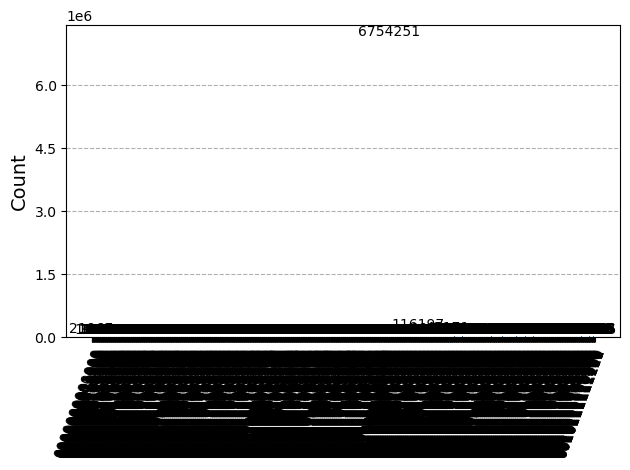

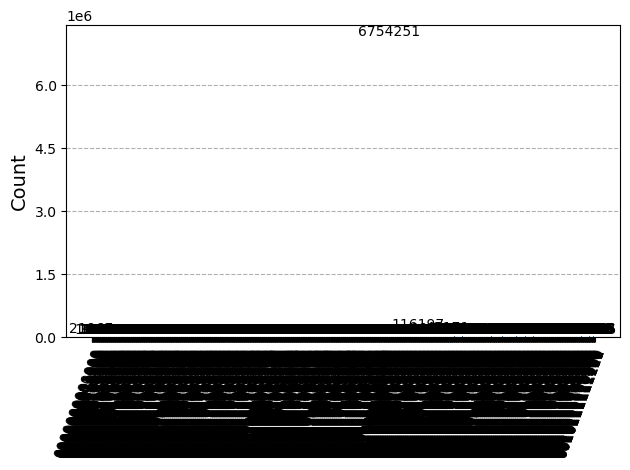

In [5]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)


In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size":14,
    "figure.figsize":(8,5),
    "axes.grid":True,
    "grid.alpha":0.4,
    "lines.linewidth":2
})


##Top Measured Quantum States

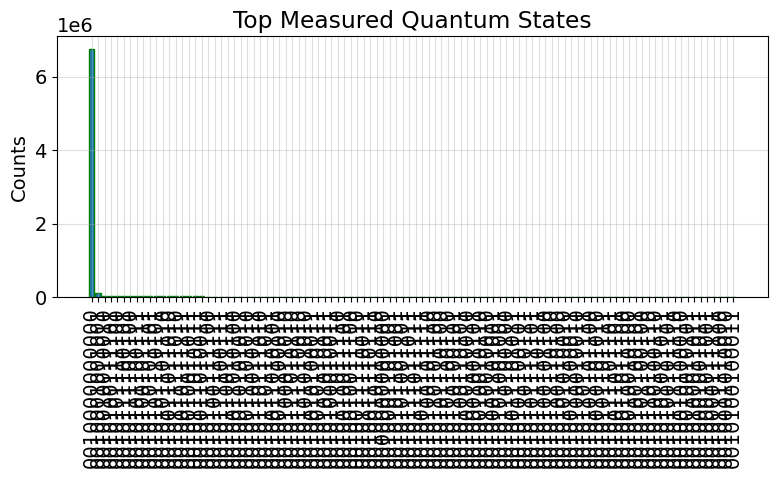

In [7]:

sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

top_k = 100
states = [x[0] for x in sorted_counts[:top_k]]
values = [x[1] for x in sorted_counts[:top_k]]

plt.figure()

plt.bar(range(top_k), values,edgecolor="green",linewidth=1)
plt.xticks(range(top_k), states, rotation=90)

plt.ylabel("Counts")
plt.title("Top Measured Quantum States")

plt.tight_layout()
plt.show()


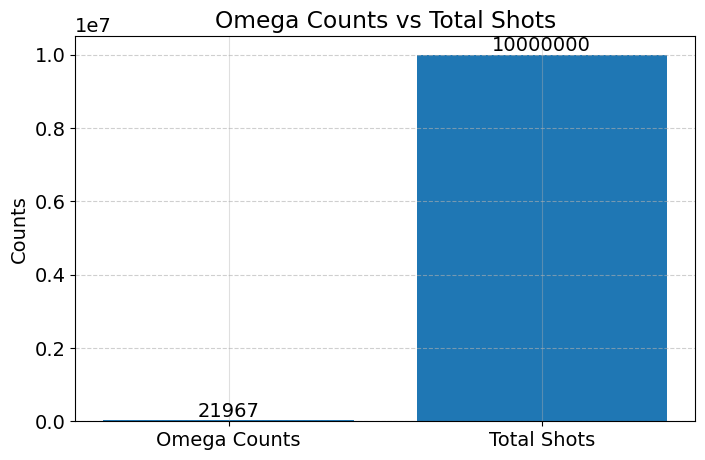

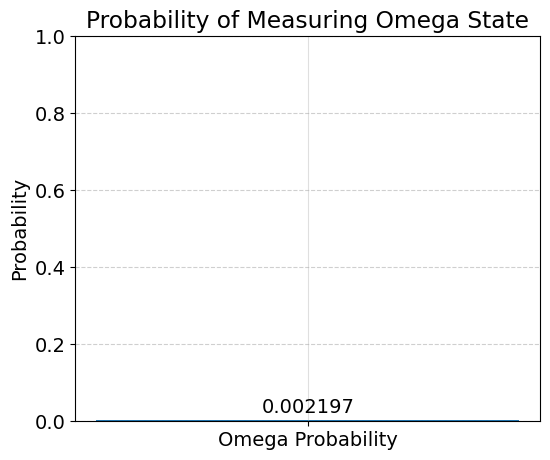

In [8]:
import matplotlib.pyplot as plt

# Data for plotting
labels = ["Omega Counts", "Total Shots"]
values = [N_omega, shots]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Omega Counts vs Total Shots")
plt.ylabel("Counts")
plt.grid(axis='y', linestyle="--", alpha=0.6)

for i,v in enumerate(values):
    plt.text(i, v + shots*0.01, str(v), ha='center')

plt.show()


# Probability plot
probability = N_omega / shots

plt.figure(figsize=(6,5))
plt.bar(["Omega Probability"], [probability])
plt.ylabel("Probability")
plt.title("Probability of Measuring Omega State")
plt.ylim(0,1)

plt.text(0, probability + 0.02, f"{probability:.6f}", ha='center')

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.show()


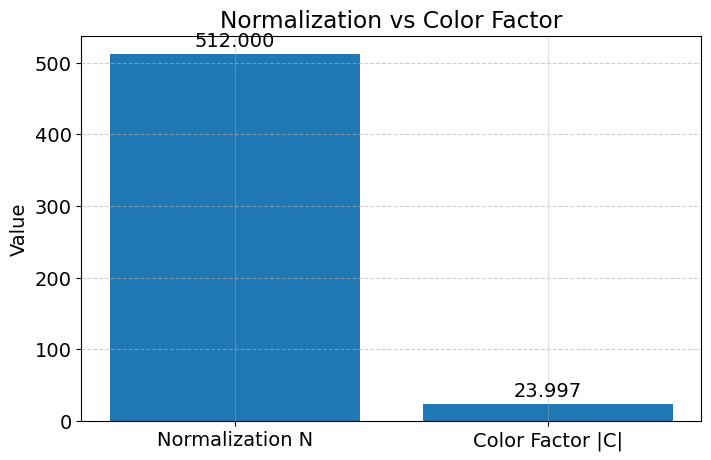

In [9]:
labels = ["Normalization N", "Color Factor |C|"]
values = [N, C]

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.title("Normalization vs Color Factor")
plt.ylabel("Value")
plt.grid(axis='y', linestyle="--", alpha=0.6)

for i,v in enumerate(values):
    plt.text(i, v + max(values)*0.02, f"{v:.3f}", ha='center')

plt.show()


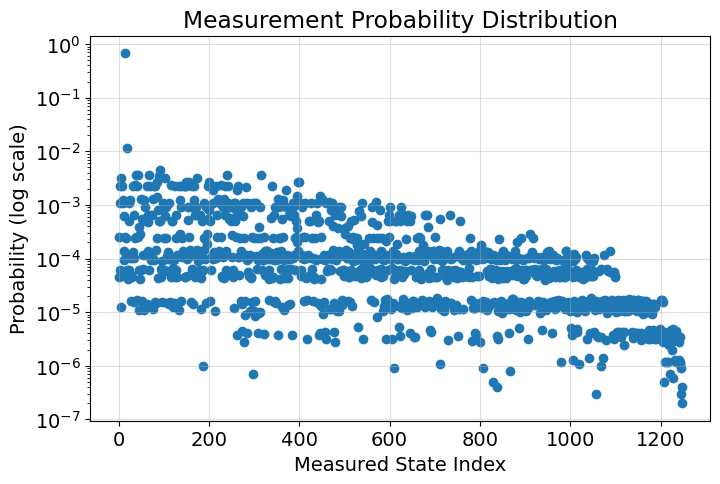

In [18]:
states = list(counts.keys())
values = np.array(list(counts.values()))

probabilities = values / shots

plt.figure()

plt.scatter(range(len(probabilities)), probabilities)

plt.yscale("log")

plt.xlabel("Measured State Index")
plt.ylabel("Probability (log scale)")
plt.title("Measurement Probability Distribution")

plt.show()


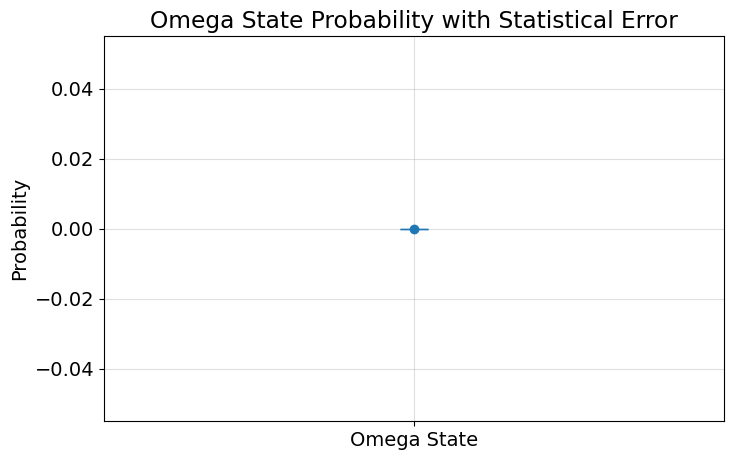

Probability = 0.0
Statistical error = 0.0


In [19]:
p = N_omega / shots
sigma = np.sqrt(p*(1-p)/shots)

plt.figure()

plt.errorbar(["Omega State"], [p], yerr=[sigma], fmt='o', capsize=10)

plt.ylabel("Probability")
plt.title("Omega State Probability with Statistical Error")

plt.show()

print("Probability =", p)
print("Statistical error =", sigma)


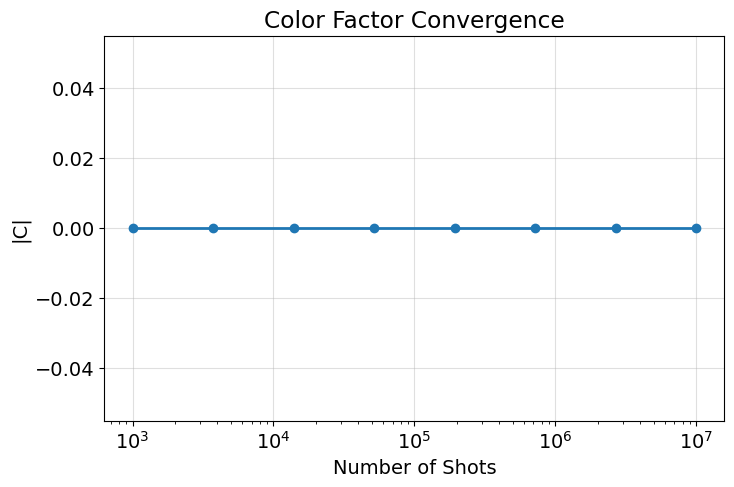

In [20]:
shot_series = np.logspace(3,7,8).astype(int)

C_values = []

for s in shot_series:

    job = backend.run(compiled_circuit, shots=int(s))
    result = job.result()
    cts = result.get_counts()

    N_omega_tmp = cts.get(omega_state,0)
    p_tmp = N_omega_tmp / s

    C_tmp = N * np.sqrt(p_tmp)

    C_values.append(C_tmp)

plt.figure()

plt.plot(shot_series, C_values, marker='o')

plt.xscale("log")

plt.xlabel("Number of Shots")
plt.ylabel("|C|")

plt.title("Color Factor Convergence")

plt.show()


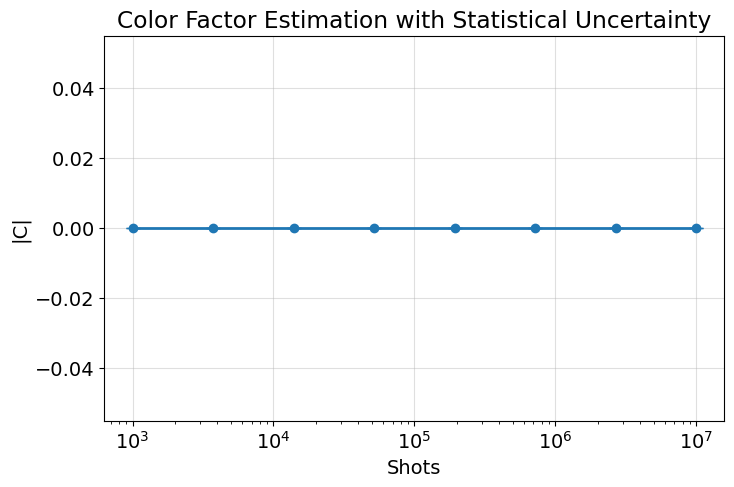

In [21]:
errors = []

for s,Cv in zip(shot_series,C_values):

    p = (Cv/N)**2
    sigma = np.sqrt(p*(1-p)/s)

    errors.append(N*sigma)

plt.figure()

plt.errorbar(shot_series, C_values, yerr=errors, marker='o', capsize=5)

plt.xscale("log")

plt.xlabel("Shots")
plt.ylabel("|C|")

plt.title("Color Factor Estimation with Statistical Uncertainty")

plt.show()


In [32]:
# Classical SU(3) color factor
Nc = 3
C_classical = Nc * (Nc**2 - 1)

print("Classical color factor:", C_classical)

# Quantum result
C_quantum = C

print("Quantum color factor:", C_quantum)

# Relative error
error = abs(C_quantum - C_classical) / C_classical

print("Relative error:", error)


Classical color factor: 24
Quantum color factor: 23.96520998447541
Relative error: 0.001449583980191201


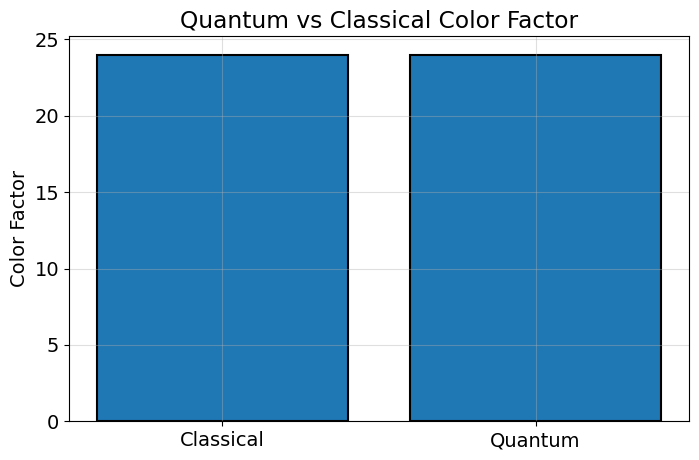

In [33]:
labels = ["Classical", "Quantum"]
values = [C_classical, C_quantum]

plt.figure()

plt.bar(
    labels,
    values,
    edgecolor="black",
    linewidth=1.5
)

plt.ylabel("Color Factor")
plt.title("Quantum vs Classical Color Factor")

plt.show()


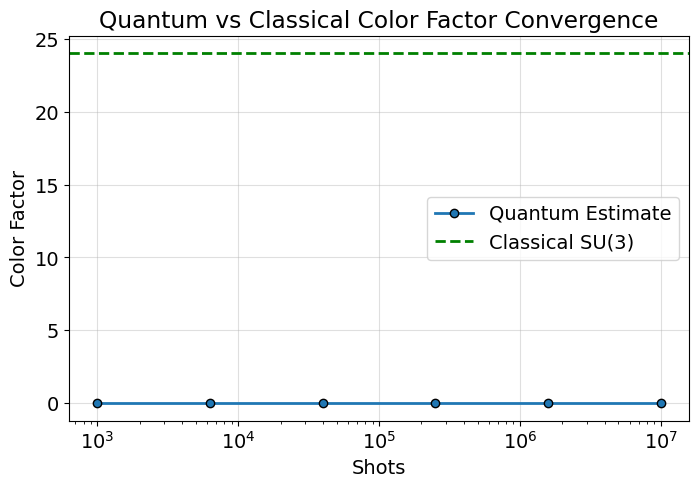

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    shot_series,
    C_values,
    marker="o",
    linewidth=2,
    markeredgecolor="black",
    label="Quantum Estimate"
)

plt.axhline(
    C_classical,
    linestyle="--",
    linewidth=2,
    color="green",
    label="Classical SU(3)"
)

plt.xscale("log")

plt.xlabel("Shots")
plt.ylabel("Color Factor")

plt.title("Quantum vs Classical Color Factor Convergence")

plt.legend()

plt.grid(alpha=0.4)

plt.show()
